## Setup

In [21]:
from tensorboard.backend.event_processing import event_accumulator
import pandas as pd
from matplotlib import pyplot as plt

kitti_print_types = [
           'Car_bev/easy_R40',        'Car_bev_relaxed/easy_R40',        'Car_3d/easy_R40',        'Car_3d_relaxed/easy_R40', 
    'Pedestrian_bev/easy_R40', 'Pedestrian_bev_relaxed/easy_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d_relaxed/easy_R40',
       'Cyclist_bev/easy_R40',    'Cyclist_bev_relaxed/easy_R40',    'Cyclist_3d/easy_R40',    'Cyclist_3d_relaxed/easy_R40'
    ]

kitti_display_types = [
           'Car BEV AP (Benchmark IoU)',        'Car BEV AP (Relaxed IoU)',        
            'Car 3D AP (Benchmark IoU)',         'Car 3D AP (Relaxed IoU)', 

    'Pedestrian BEV AP (Benchmark IoU)', 'Pedestrian BEV AP (Relaxed IoU)', 
     'Pedestrian 3D AP (Benchmark IoU)',  'Pedestrian 3D AP (Relaxed IoU)',

       'Cyclist BEV AP (Benchmark IoU)',    'Cyclist BEV AP (Relaxed IoU)',    
        'Cyclist 3D AP (Benchmark IoU)',  'Cyclist AP 3D AP (Relaxed IoU)',
    ]


nusc_print_types = [
    'NuScenes/AP/car/0.5m', 'NuScenes/AP/pedestrian/0.5m', 'NuScenes/AP/bicycle/0.5m',
    'NuScenes/AP/car/1.0m', 'NuScenes/AP/pedestrian/1.0m', 'NuScenes/AP/bicycle/1.0m',
    ]

nusc_display_types = [
    'Car AP (0.5m)',  'Pedestrian AP (0.5m)',    'Cyclist AP (0.5m)',        
    'Car AP (1.0m)',  'Pedestrian AP (1.0m)',    'Cyclist AP (1.0m)',    
    ]

def print_tb(dataset=None,log_dir=None):
    ea = event_accumulator.EventAccumulator(log_dir)
    ea.Reload()
    scalar_tags = ea.Tags()['scalars']
    print(scalar_tags)

    matched_metrics = [
        (tag, display_type)
        for tag, display_type in zip(kitti_print_types, kitti_display_types)
        if tag in scalar_tags
    ]
    nusc_matched_metrics = [
        (tag, display_type)
        for tag, display_type in zip(nusc_print_types, nusc_display_types)
        if tag in scalar_tags
    ]
    if matched_metrics:
        n_plots = len(matched_metrics)
        n_cols = 4
        n_rows = (n_plots + n_cols - 1) // n_cols
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), sharex=False)
        axs = axs.flatten() if n_plots > 1 else [axs]

        for ax in axs[n_plots:]:
            ax.axis('off')

        for ax, (tag, display_type) in zip(axs, matched_metrics):
            data = [(s.step, s.value) for s in ea.Scalars(tag)]
            df = pd.DataFrame(data, columns=['epoch', 'perf'])
            ax.plot(df['epoch'], df['perf'], linewidth=1.5)
            ax.set_title(display_type, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Average Precision')
            ax.grid(True, linestyle='--', alpha=0.6)
        if dataset == 'KITTI':
            plt.suptitle('KITTI', fontsize=24, fontweight='bold', y=0.995)
        else:
            plt.suptitle('eRod', fontsize=24, fontweight='bold', y=0.995)
        plt.tight_layout()
        plt.show()
        return

    elif 'NDS' in scalar_tags:
        """data = [(s.step, s.value) for s in ea.Scalars('NDS')]
        df = pd.DataFrame(data, columns=['Step', 'NDS'])
        df.plot(x='Step', y='NDS', kind='line', grid=True, title='NDS')
        plt.show()"""
        n_plots = len(nusc_matched_metrics)
        n_cols = 3
        n_rows = (n_plots + n_cols - 1) // n_cols
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), sharex=False)
        axs = axs.flatten() if n_plots > 1 else [axs]

        for ax in axs[n_plots:]:
            ax.axis('off')

        for ax, (tag, display_type) in zip(axs, nusc_matched_metrics):
            data = [(s.step, s.value) for s in ea.Scalars(tag)]
            df = pd.DataFrame(data, columns=['epoch', 'perf'])
            ax.plot(df['epoch'], df['perf'], linewidth=1.5)
            ax.set_title(display_type, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Average Precision')
            ax.grid(True, linestyle='--', alpha=0.6)

        plt.suptitle('nuScenes', fontsize=24, fontweight='bold', y=0.995)
        plt.tight_layout()
        plt.show()
        return


    elif 'train/loss' in scalar_tags:
        data = [(s.step, s.value) for s in ea.Scalars('train/loss')]
        df = pd.DataFrame(data, columns=['Step', 'Loss'])
        df.plot(x='Step', y='Loss', kind='line', grid=True, title='Loss')
        plt.show()
    return
    


In [22]:
log_test = {
    "S_F_def": {
        "N": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_N/default/eval/eval_all_default/default/tensorboard_val",
        "E": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_E/default/eval/eval_all_default/default_def/tensorboard_val_all",
    },
    "P_D_ftd": {
        "K": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/D/P_D_K/default/eval/eval_all_default/default/tensorboard_val",
        "E": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/D/P_D_E/default/eval/eval_all_default/default_0/tensorboard_val_all",
    },
    "S_D_ftd": {
        "K": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/D/S_D_K/default/eval/eval_all_default/default/tensorboard_val",
        "E": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/D/S_D_E/default/eval/eval_all_default/default/tensorboard_val_all",
    },
    "S_F_ftd": {
        "K": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_K/default/eval/eval_all_default/default/tensorboard_val",
        "N": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_N/default/eval/eval_all_default/default/tensorboard_val",
        "E": "/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_E/default/eval/eval_all_default/default_ftd/tensorboard_val_all",
    }
}


In [23]:
log_train = {
    "P_ftd"       :"/OpenPCDet/output/OpenPCDet/tools/cfgs/models/P/D/P_D_N/unfrozen_backbone_1/tensorboard",
    "S_ftd"       :"/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/D/S_D_N/unfrozen_backbone_1_94/tensorboard",    
    "S_focals_def":"/OpenPCDet/output/cfgs/models/S/F/S_F_K/default/tensorboard", 
    "S_focals_ftd":"/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/F/S_F_N/default/tensorboard",
    }



# TEST

## SECOND (DEFAULT)

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Pedestrian_3d_rela

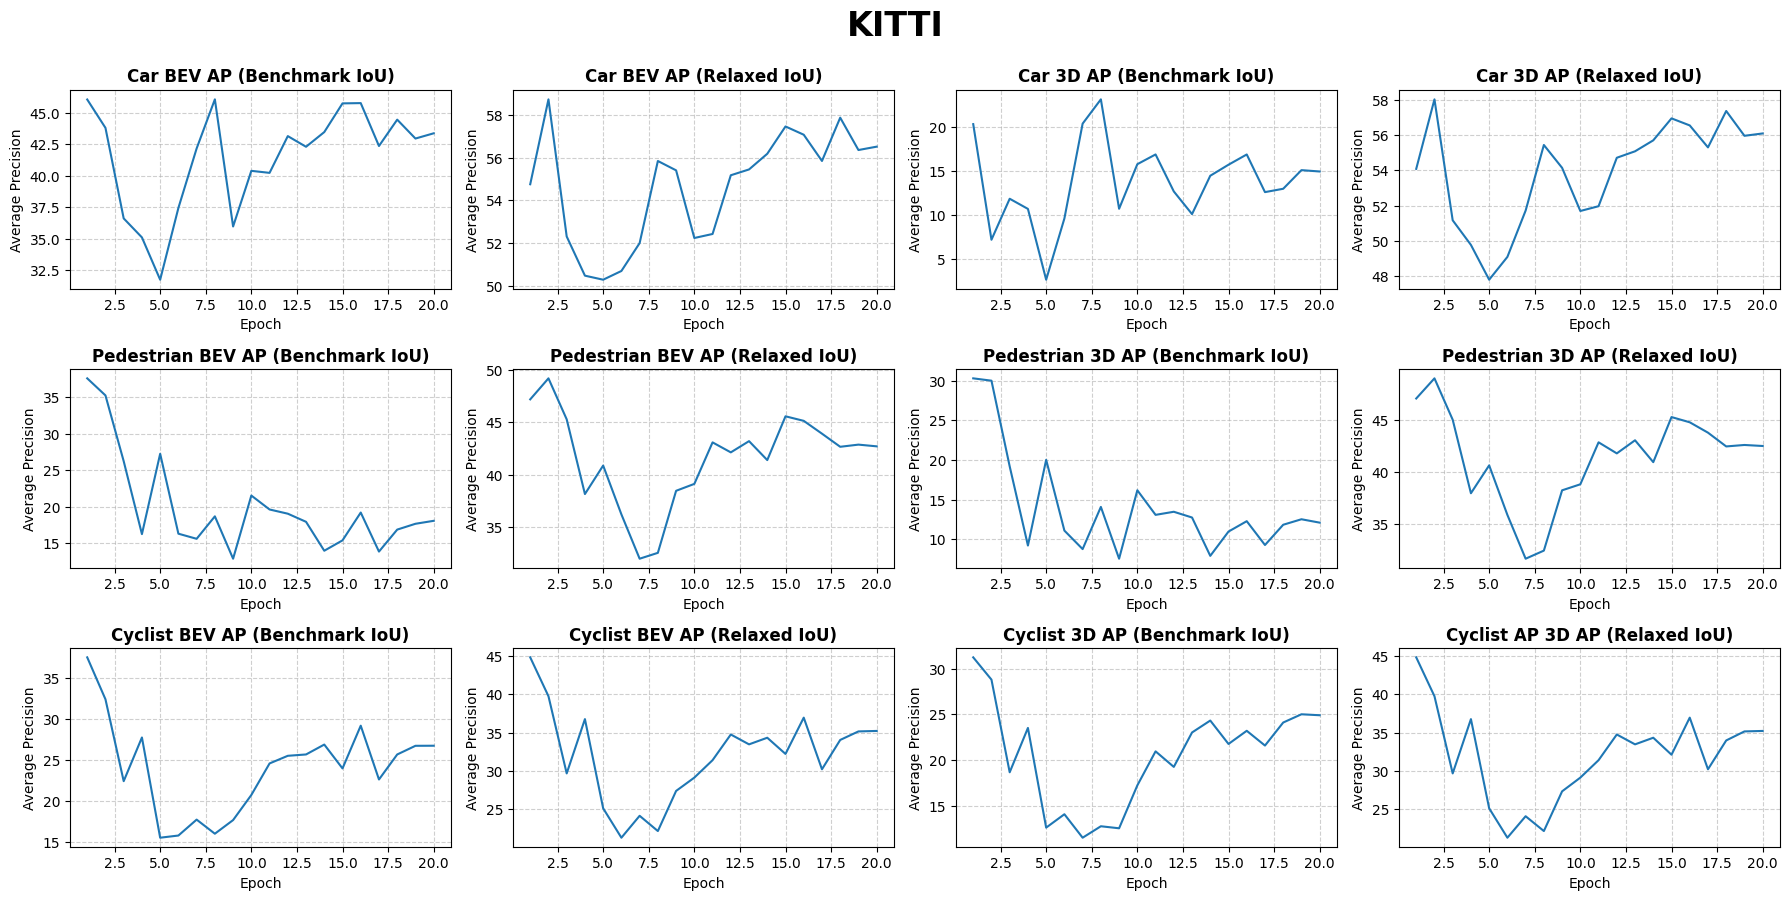

In [24]:
print_tb("KITTI",log_test["S_D_ftd"]["K"])

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Pedestrian_3d_rela

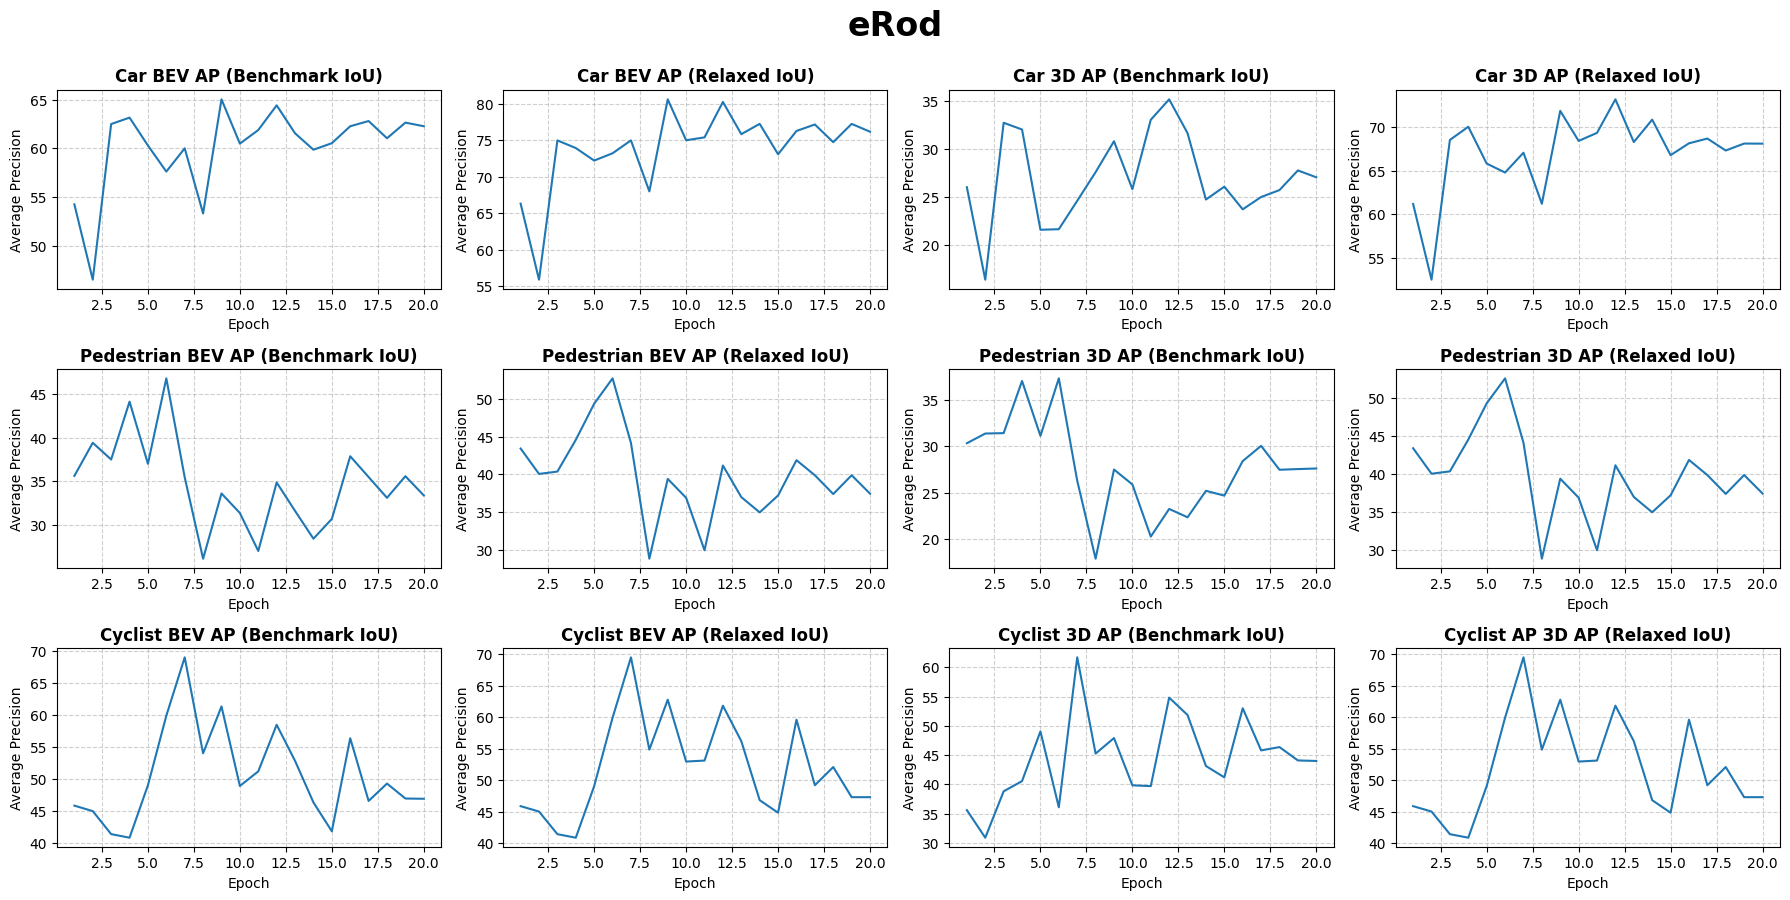

In [25]:
print_tb("eRod",log_test["S_D_ftd"]["E"])

## SECOND (FOCALS)

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'trans_err', 'scale_err', 'orient_err', 'vel_err', 'attr_err', 'NuScenes/AP/car/0.5m', 'NuScenes/AP/car/1.0m', 'NuScenes/AP/car/2.0m', 'NuScenes/AP/car/4.0m', 'NuScenes/AP/car/mean_distance', 'NuScenes/AP/truck/0.5m', 'NuScenes/AP/truck/1.0m', 'NuScenes/AP/truck/2.0m', 'NuScenes/AP/truck/4.0m', 'NuScenes/AP/truck/mean_distance', 'NuScenes/AP/bus/0.5m', 'NuScenes/AP/bus/1.0m', 'NuScenes/AP/bus/2.0m', 'NuScenes/AP/bus/4.0m', 'NuScenes/AP/bus/mean_distance', 'NuScenes/AP/trailer/0.5m', 'NuScenes/AP/trailer/1.0m', 'NuScenes/AP/trailer/2.0m', 'NuScenes/AP/trailer/4.0m', 'NuScenes/AP/trailer/mean_distance', 'NuScenes/AP/construction_vehicle/0.5m', 'NuScenes/AP/construction_vehicle/1.0m', 'NuScenes/AP/construction_vehicle/2.0m', 'NuScenes/AP/construction_vehicle/4.0m', 'NuScenes/AP/construction_vehicle/mean_distance', 'NuScenes/AP/pedestrian/0.5m', 'NuScenes/AP/pedestrian/1.0m', 'Nu

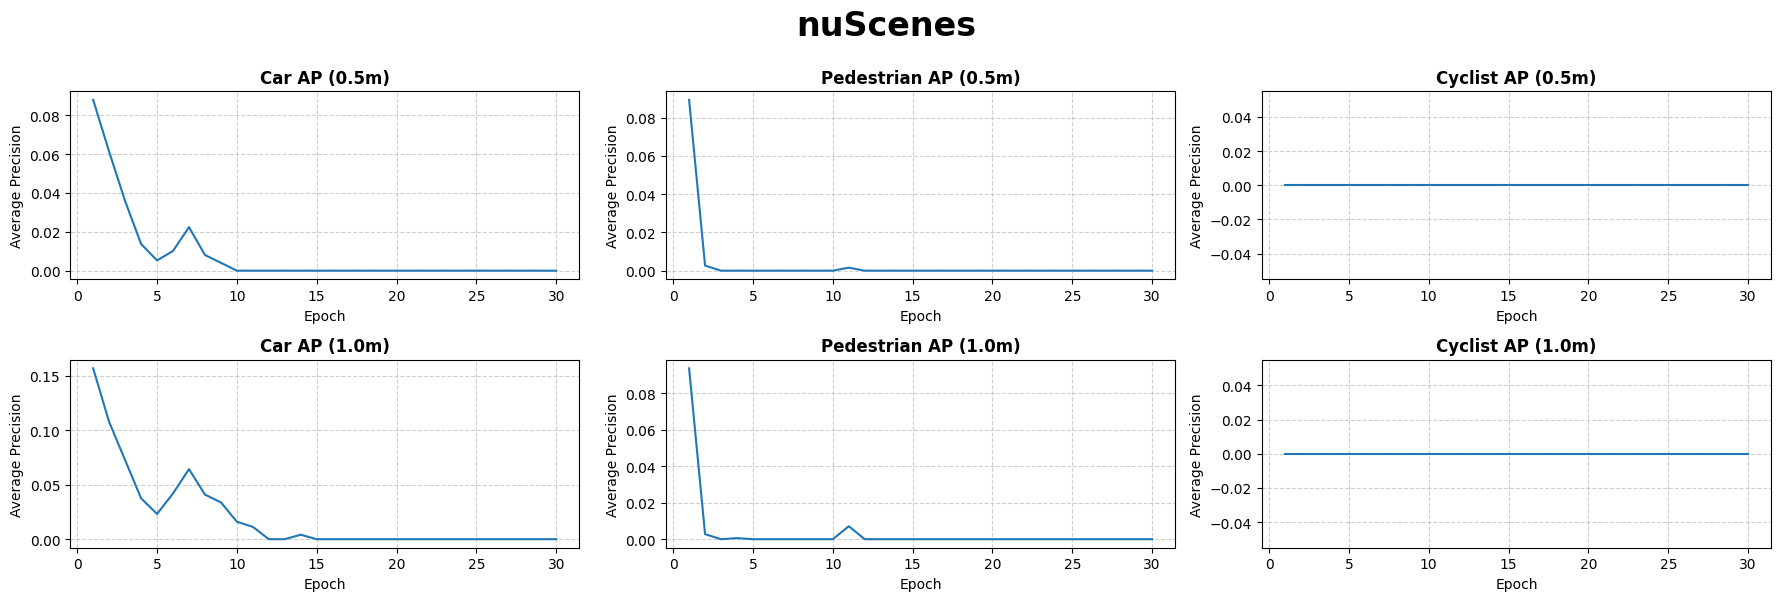

In [26]:
print_tb("nuScenes",log_test["S_F_def"]["N"])

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Pedestrian_3d_rela

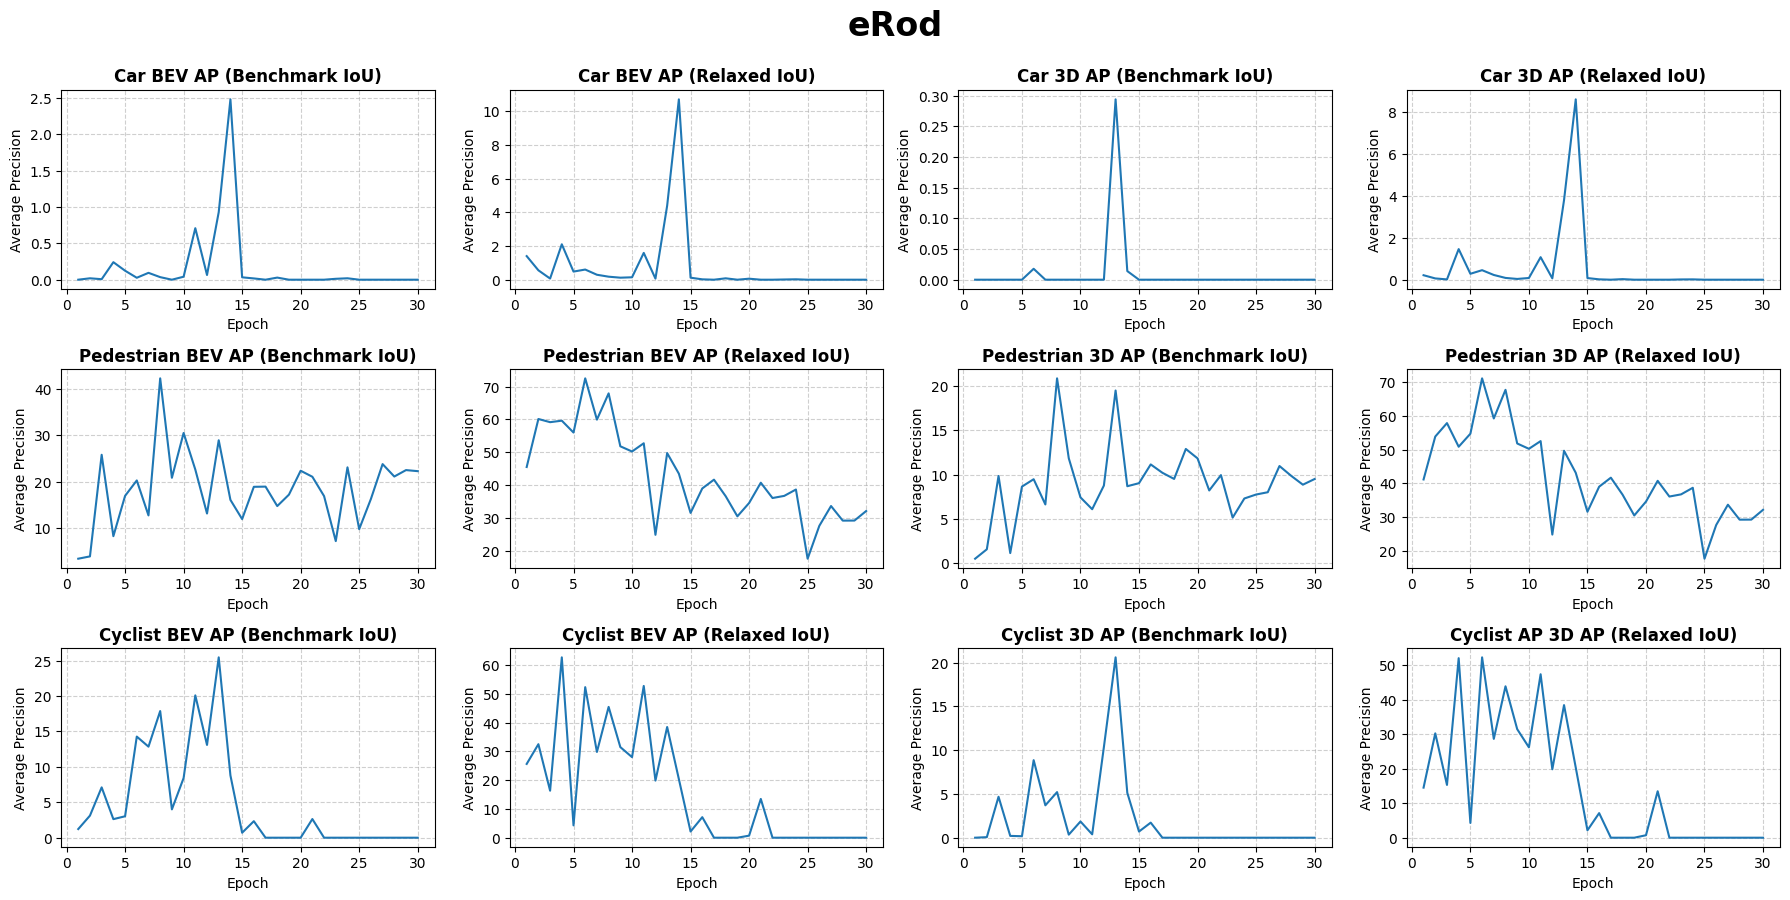

In [27]:
print_tb("eRod",log_test["S_F_def"]["E"])

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Pedestrian_3d_rela

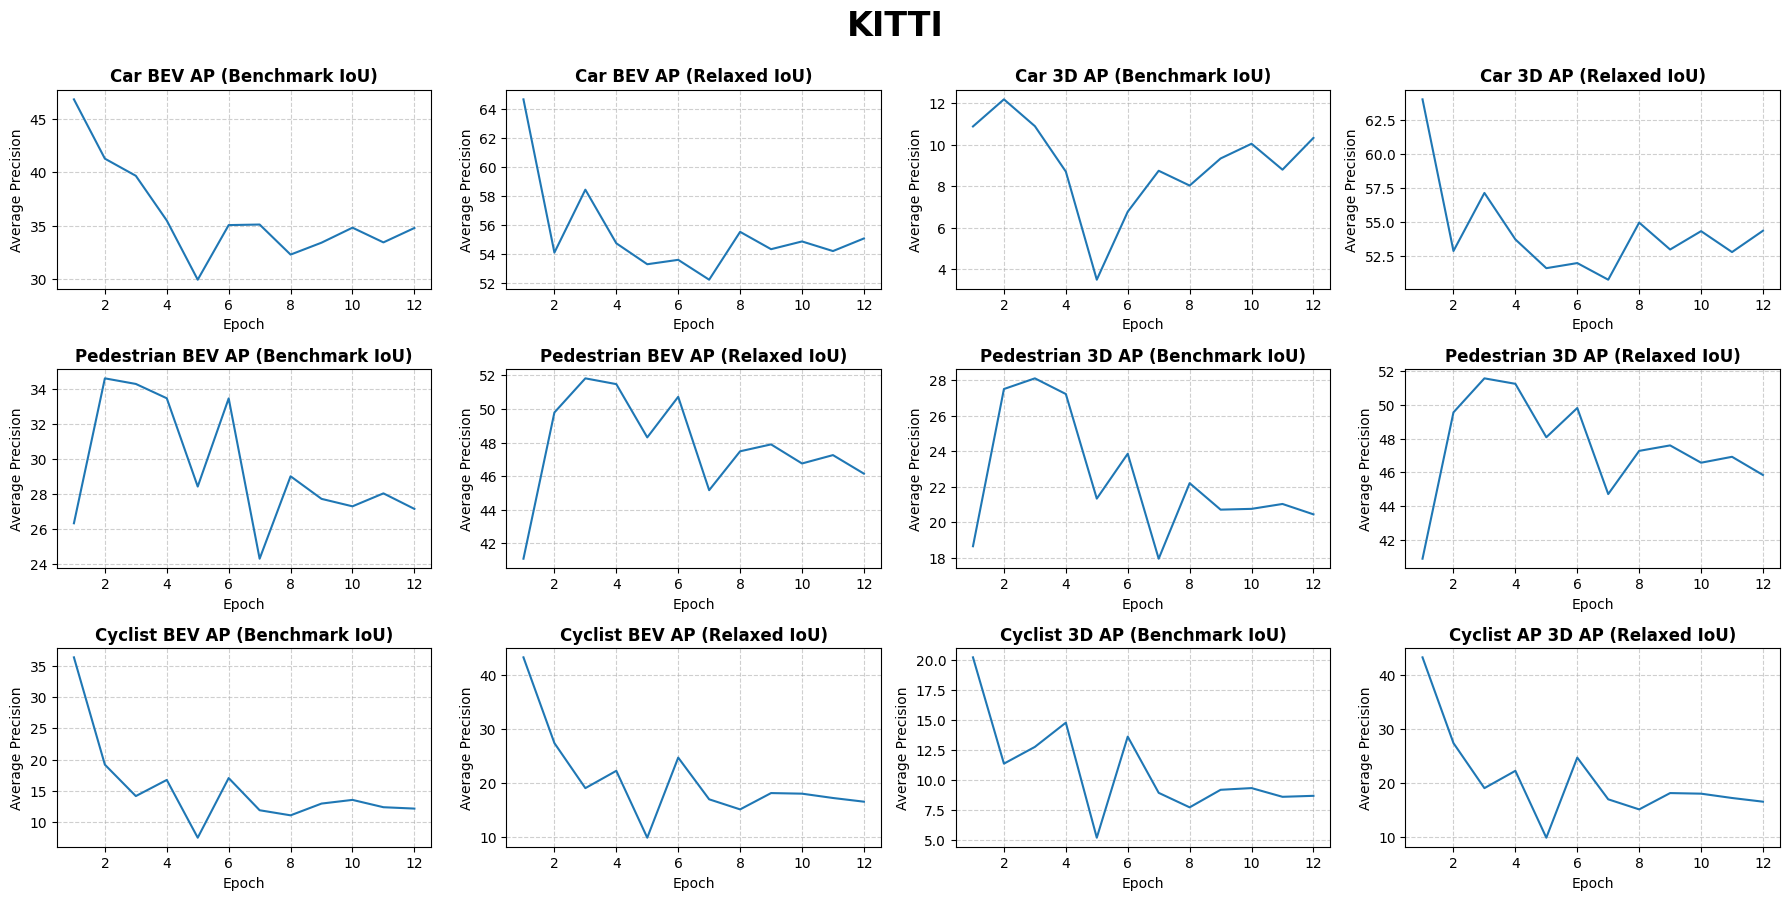

In [28]:
print_tb("KITTI",log_test["S_F_ftd"]["K"])

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Pedestrian_3d_rela

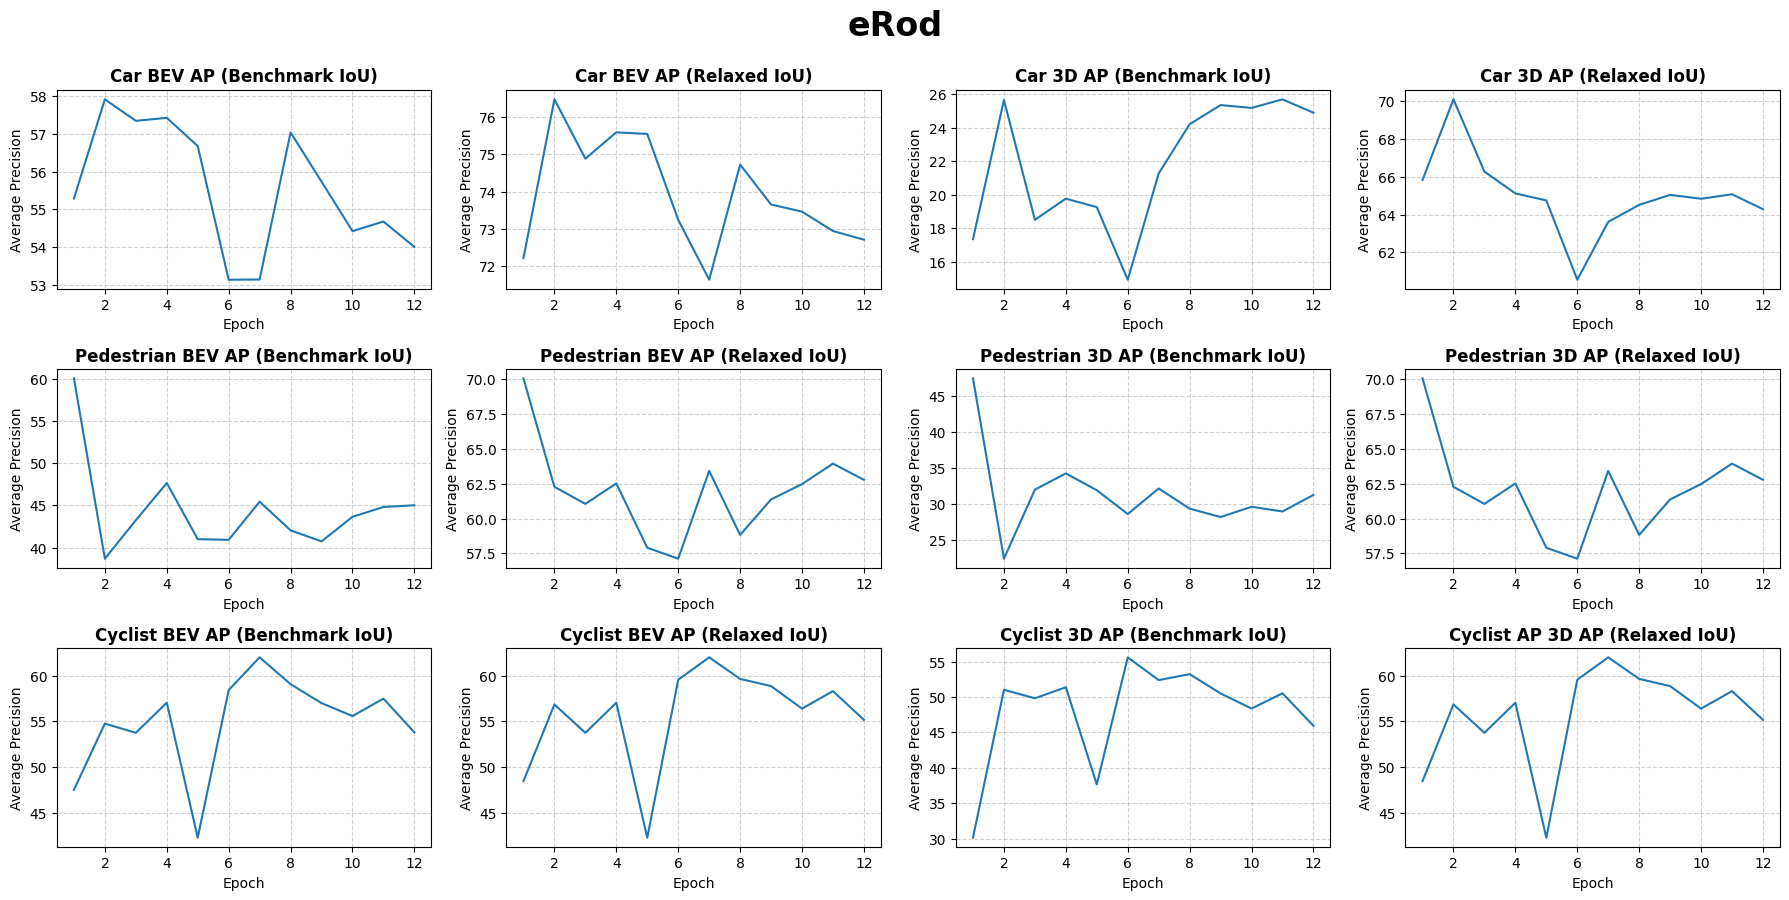

In [29]:
print_tb("eRod",log_test["S_F_ftd"]["E"])

## POINTPILLARS (DEFAULT)

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Pedestrian_3d_rela

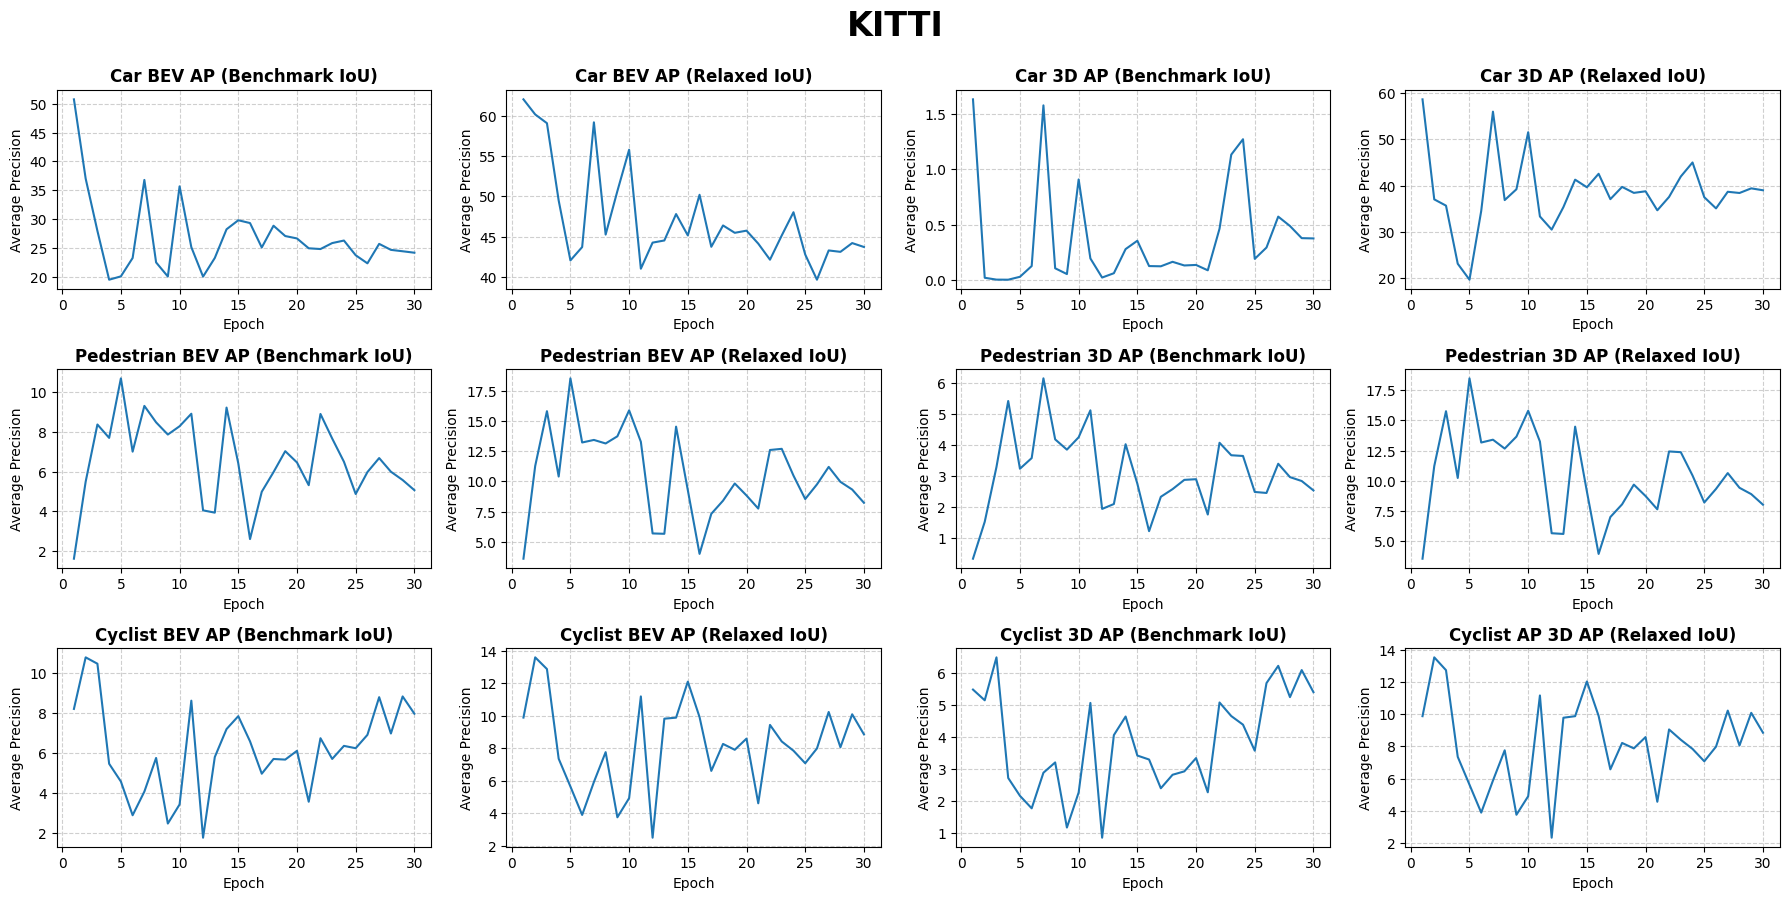

In [30]:
print_tb("KITTI",log_test["P_D_ftd"]["K"])

['recall/roi_0.3', 'recall/rcnn_0.3', 'recall/roi_0.5', 'recall/rcnn_0.5', 'recall/roi_0.7', 'recall/rcnn_0.7', 'Car_aos/easy_R40', 'Car_aos/moderate_R40', 'Car_aos/hard_R40', 'Car_3d/easy_R40', 'Car_3d/moderate_R40', 'Car_3d/hard_R40', 'Car_bev/easy_R40', 'Car_bev/moderate_R40', 'Car_bev/hard_R40', 'Car_image/easy_R40', 'Car_image/moderate_R40', 'Car_image/hard_R40', 'Car_3d_relaxed/easy_R40', 'Car_3d_relaxed/moderate_R40', 'Car_3d_relaxed/hard_R40', 'Car_bev_relaxed/easy_R40', 'Car_bev_relaxed/moderate_R40', 'Car_bev_relaxed/hard_R40', 'Car_image_relaxed/easy_R40', 'Car_image_relaxed/moderate_R40', 'Car_image_relaxed/hard_R40', 'Pedestrian_aos/easy_R40', 'Pedestrian_aos/moderate_R40', 'Pedestrian_aos/hard_R40', 'Pedestrian_3d/easy_R40', 'Pedestrian_3d/moderate_R40', 'Pedestrian_3d/hard_R40', 'Pedestrian_bev/easy_R40', 'Pedestrian_bev/moderate_R40', 'Pedestrian_bev/hard_R40', 'Pedestrian_image/easy_R40', 'Pedestrian_image/moderate_R40', 'Pedestrian_image/hard_R40', 'Pedestrian_3d_rela

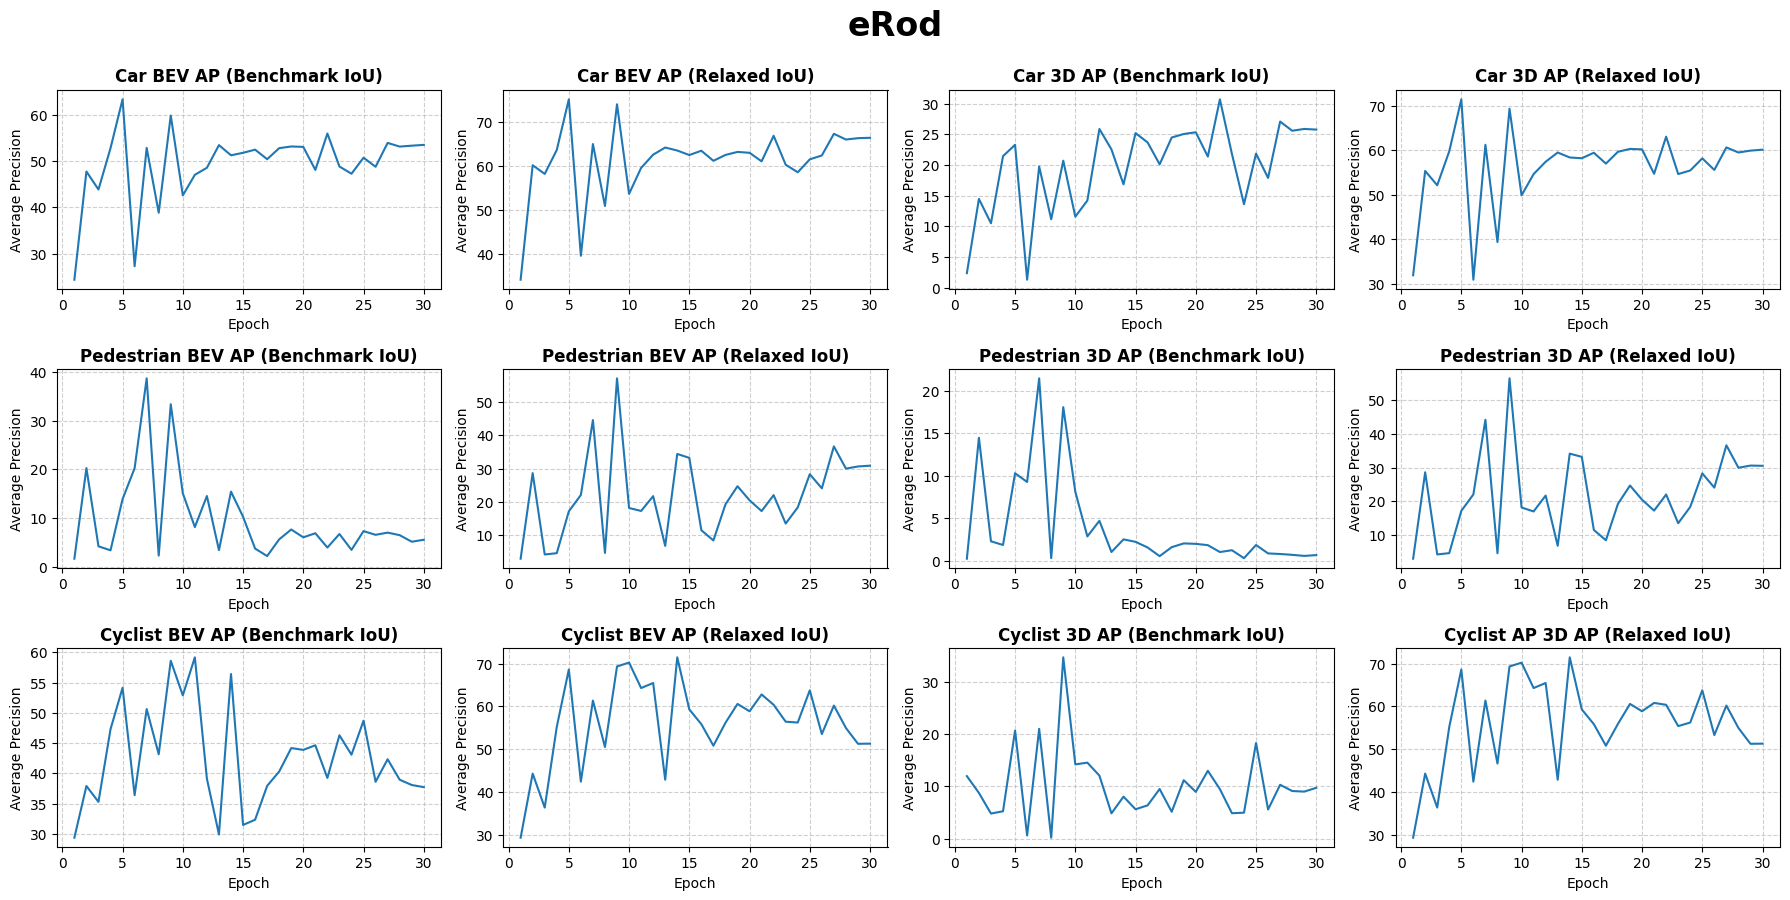

In [31]:
print_tb("eRod",log_test["P_D_ftd"]["E"])